# Data Preprocessing - Day 19

**Project**: Bank Marketing Campaign Prediction  
**Date**: Week 4, Day 19  
**Task**: Clean data, encode categorical variables, scale features, handle imbalance

---

## Table of Contents
1. Import Libraries
2. Load Cleaned Data
3. Separate Features and Target
4. Encode Categorical Variables
5. Scale Numerical Features
6. Handle Class Imbalance (SMOTE)
7. Train-Test Split
8. Save Processed Data

In [2]:
# %%
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [3]:
# %%
# ============================================
# 2. LOAD DATASET
# ============================================

# Load the dataset from the previous step
try:
    df = pd.read_csv('../data/raw/bank-full.csv', sep=';')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except:
    print("Using sample dataset...")
    # Sample data (same as previous notebook)
    sample_data = {
        'age': [30, 45, 25, 50, 35, 60, 22, 48, 33, 55, 40, 28, 52, 38, 42],
        'job': ['admin', 'technician', 'services', 'management', 'retired', 
                'admin', 'student', 'technician', 'management', 'services',
                'blue-collar', 'admin', 'management', 'technician', 'retired'],
        'marital': ['married', 'single', 'married', 'divorced', 'married',
                    'single', 'single', 'married', 'divorced', 'married',
                    'married', 'single', 'married', 'divorced', 'married'],
        'education': ['university', 'university', 'high_school', 'university', 'university',
                      'high_school', 'university', 'university', 'high_school', 'university',
                      'basic.9y', 'university', 'university', 'high_school', 'university'],
        'default': ['no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
                    'no', 'no', 'no', 'no', 'no'],
        'housing': ['yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'yes',
                    'yes', 'yes', 'no', 'yes', 'yes'],
        'loan': ['no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no',
                 'no', 'no', 'yes', 'no', 'no'],
        'contact': ['cellular', 'cellular', 'telephone', 'cellular', 'cellular',
                    'cellular', 'cellular', 'telephone', 'cellular', 'cellular',
                    'cellular', 'cellular', 'telephone', 'cellular', 'cellular'],
        'month': ['may', 'may', 'june', 'june', 'may', 'may', 'july', 'june', 'may', 'june',
                  'may', 'may', 'june', 'july', 'may'],
        'day_of_week': ['mon', 'tue', 'wed', 'thu', 'fri', 'mon', 'tue', 'wed', 'thu', 'fri',
                        'mon', 'tue', 'wed', 'thu', 'fri'],
        'duration': [200, 150, 300, 250, 180, 400, 100, 350, 220, 280,
                     190, 210, 320, 170, 260],
        'campaign': [1, 2, 3, 1, 2, 1, 4, 2, 1, 3, 2, 1, 3, 2, 1],
        'pdays': [999, 999, 999, 999, 999, 999, 999, 999, 999, 999,
                  999, 999, 999, 999, 999],
        'previous': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        'poutcome': ['none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none',
                     'none', 'none', 'none', 'none', 'none'],
        'emp_var_rate': [1.4, 1.4, -1.1, -1.1, 1.4, 1.4, -1.1, -1.1, 1.4, 1.4,
                         1.4, 1.4, -1.1, -1.1, 1.4],
        'cons_price_idx': [92.89, 92.89, 93.08, 93.08, 92.89, 92.89, 93.08, 93.08, 92.89, 92.89,
                           92.89, 92.89, 93.08, 93.08, 92.89],
        'cons_conf_idx': [-36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1,
                          -36.1, -36.1, -36.1, -36.1, -36.1],
        'euribor3m': [4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86,
                      4.86, 4.86, 4.86, 4.86, 4.86],
        'nr_employed': [5167.0, 5167.0, 5108.0, 5108.0, 5167.0, 5167.0, 5108.0, 5108.0, 5167.0, 5167.0,
                        5167.0, 5167.0, 5108.0, 5108.0, 5167.0],
        'y': ['no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'no', 'no',
              'no', 'no', 'yes', 'no', 'no']
    }
    df = pd.DataFrame(sample_data)
    print(f"Created sample dataset: {df.shape[0]} rows")

Dataset loaded successfully!
Shape: (41188, 21)


## 3. Separate Features and Target

In [4]:
# %%
# ============================================
# 3. SEPARATE FEATURES AND TARGET
# ============================================

# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (41188, 20)
Target shape: (41188,)

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64


## 4. Encode Categorical Variables

In [5]:
# %%
# ============================================
# 4. ENCODE CATEGORICAL VARIABLES
# ============================================

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# %%
# Method 1: One-Hot Encoding (for categorical)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nShape after one-hot encoding: {X_encoded.shape}")
print(f"New features: {X_encoded.columns.tolist()[:10]}...")

# %%
# Method 2: Label Encoding (alternative for tree-based models)
# This is another option - we'll use one-hot for now
from sklearn.preprocessing import LabelEncoder

X_label_encoded = X.copy()
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_label_encoded[col] = le.fit_transform(X_label_encoded[col])
    le_dict[col] = le

print("\nLabel encoding alternative:")
print(X_label_encoded[categorical_cols].head())

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Shape after one-hot encoding: (41188, 53)
New features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']...

Label encoding alternative:
   job  marital  education  default  housing  loan  contact  month  \
0    3        1          0        0        0     0        1      6   
1    7        1          3        1        0     0        1      6   
2    7        1          3        0        2     0        1      6   
3    0        1          1        0        0     0        1      6   
4    7        1          3        0        0     2        1      6   

   day_of_week  poutcome  
0            1         1  
1            1         

## 5. Scale Numerical Features

Features scaled successfully!
Mean of scaled features: -0.00
Std of scaled features: 1.00


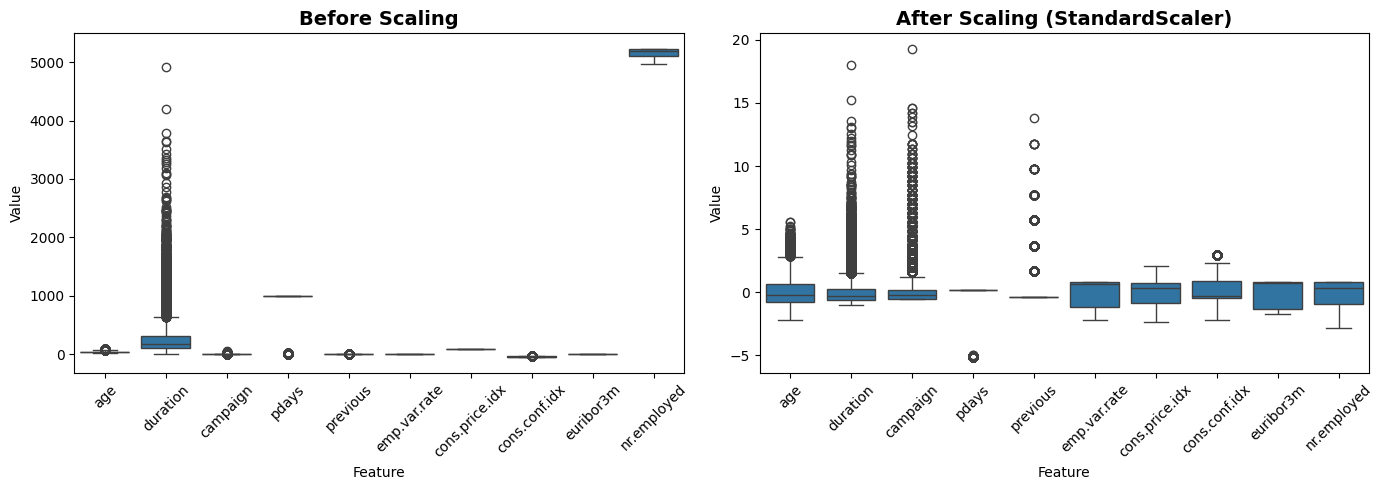

In [6]:
# %%
# ============================================
# 5. SCALE NUMERICAL FEATURES
# ============================================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale numerical features
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

print("Features scaled successfully!")
print(f"Mean of scaled features: {X_scaled[numerical_cols].mean().mean():.2f}")
print(f"Std of scaled features: {X_scaled[numerical_cols].std().mean():.2f}")

# %%
# Visualize before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
X_before = X_encoded[numerical_cols].melt(var_name='Feature', value_name='Value')
sns.boxplot(data=X_before, x='Feature', y='Value', ax=axes[0])
axes[0].set_title('Before Scaling', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# After scaling
X_after = X_scaled[numerical_cols].melt(var_name='Feature', value_name='Value')
sns.boxplot(data=X_after, x='Feature', y='Value', ax=axes[1])
axes[1].set_title('After Scaling (StandardScaler)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/eda_plots/scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Handle Class Imbalance (SMOTE)

Original class distribution:
Counter({'no': 36548, 'yes': 4640})

Class distribution after SMOTE:
Counter({0: 36548, 1: 36548})

New dataset shape: (73096, 53)


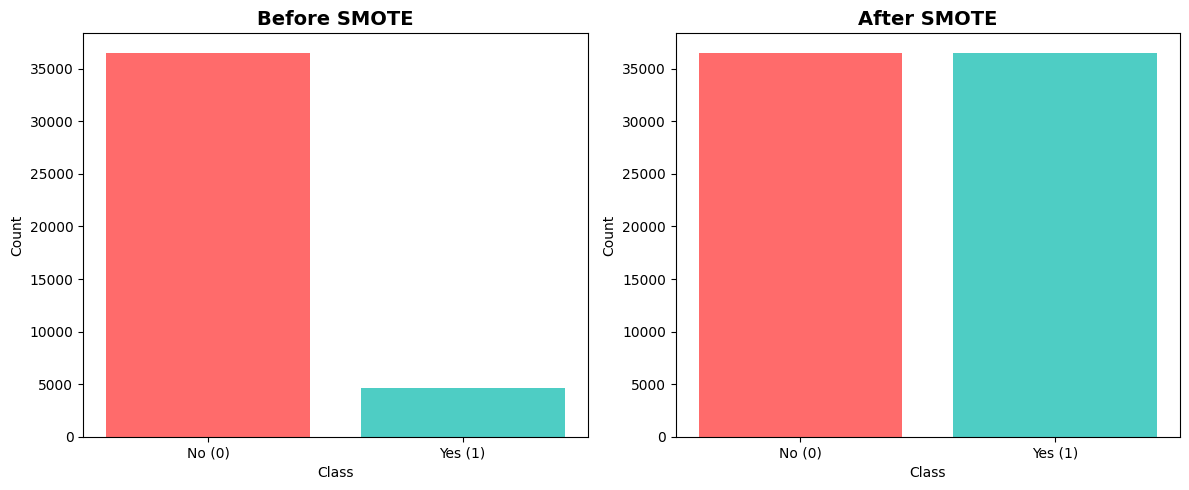

In [7]:
# %%
# ============================================
# 6. HANDLE CLASS IMBALANCE (SMOTE)
# ============================================

# Check original class distribution
print("Original class distribution:")
print(Counter(y))

# Encode target for SMOTE
y_encoded = y.map({'yes': 1, 'no': 0})

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

print("\nClass distribution after SMOTE:")
print(Counter(y_resampled))
print(f"\nNew dataset shape: {X_resampled.shape}")

# %%
# Visualize class balance before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
before_counts = Counter(y_encoded)
axes[0].bar(before_counts.keys(), before_counts.values(), color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (0)', 'Yes (1)'])

# After SMOTE
after_counts = Counter(y_resampled)
axes[1].bar(after_counts.keys(), after_counts.values(), color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.savefig('../outputs/eda_plots/smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Train-Test Split

In [8]:
# %%
# ============================================
# 7. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(Counter(y_train))
print(f"\nTest target distribution:")
print(Counter(y_test))

Training set: 58476 samples
Test set: 14620 samples

Training target distribution:
Counter({1: 29238, 0: 29238})

Test target distribution:
Counter({0: 7310, 1: 7310})


## 8. Save Processed Data

In [9]:
# %%
# ============================================
# 8. SAVE PROCESSED DATA
# ============================================

# Create processed directory if not exists
import os
os.makedirs('../data/processed', exist_ok=True)

# Save preprocessed data
pd.DataFrame(X_train).to_csv('../data/processed/X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('../data/processed/X_test.csv', index=False)
pd.DataFrame(y_train, columns=['target']).to_csv('../data/processed/y_train.csv', index=False)
pd.DataFrame(y_test, columns=['target']).to_csv('../data/processed/y_test.csv', index=False)

print("Processed data saved successfully!")
print(f"Location: ../data/processed/")

# Also save the scaler and encoders for later use
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le_dict, '../models/label_encoders.pkl')

print("Scaler and encoders saved!")

Processed data saved successfully!
Location: ../data/processed/
Scaler and encoders saved!
